# Definitive Meta-Analysis of RAMA/CAMA Experiments

**Evidence Classification, Pooled Effect Sizes, and Publication Readiness**

This notebook performs a rigorous meta-analysis of RAMA/CAMA experiments across 9 dependencies (iterations 2-3):

1. **Phase A**: Evidence classification (GREEN/YELLOW/RED) for each experiment task
2. **Phase B**: Per-task Cohen's d with bootstrap confidence intervals
3. **Phase C**: DerSimonian-Laird random-effects meta-analysis under multiple scenarios
4. **Phase D**: Subgroup analysis (regression vs classification, val-vs-test inflation)
5. **Phase E**: Avito safety assessment
6. **Phase F**: Publication readiness scorecard

Key findings: GREEN-only pooled d=0.297 (fails d>0.4 threshold), massive val-test inflation, rank conditioning adds no value (CAMA not RAMA), publication not ready.

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# loguru — NOT on Colab, always install
_pip('loguru==0.7.3')

# Core packages (pre-installed on Colab, install locally to match Colab env)
if 'google.colab' not in sys.modules:
    # Colab has Python 3.12; locally use compatible versions
    _pip('numpy==2.0.2', 'matplotlib==3.10.0', 'tabulate==0.9.0')
    _pip('scipy>=1.13,<1.16')  # scipy 1.16+ needs Python >=3.11


[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: python3 -m pip install --upgrade pip



[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: python3 -m pip install --upgrade pip



[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: python3 -m pip install --upgrade pip


In [2]:
import json
import math
import os
import sys
import time
from typing import NamedTuple

import numpy as np
from scipy import stats
from loguru import logger
import matplotlib.pyplot as plt
from tabulate import tabulate

logger.remove()
logger.add(sys.stdout, level="INFO", format="{time:HH:mm:ss}|{level:<7}|{message}")
print("Imports OK")

Imports OK


In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/ai-inventor-papers/ai-invention-9b0386-rank-aware-moment-aggregation-diversity-/main/evaluation_iter4_definitive_meta/demo/mini_demo_data.json"

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception:
        pass
    if os.path.exists("mini_demo_data.json"):
        with open("mini_demo_data.json") as f:
            return json.load(f)
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
print(f"Loaded {len(data['tasks'])} task results")
for t in data['tasks'][:3]:
    print(f"  {t['task_name']} ({t['evidence_grade']}, {t['eval_set']}): "
          f"{len(t['baseline_seeds'])} seeds")

Loaded 18 task results
  rel-f1/driver-dnf (GREEN, test): 5 seeds
  rel-f1/driver-position (GREEN, test): 5 seeds
  rel-stack/post-votes (RED, test): 5 seeds


## Configuration

Tunable parameters for the meta-analysis. `N_BOOTSTRAP` controls the number of bootstrap resamples for confidence intervals (original: 10,000).

In [5]:
# ---- Tunable parameters ----
N_BOOTSTRAP = 10_000       # Bootstrap resamples for CIs (full original value)
RANDOM_SEED = 42
RNG = np.random.default_rng(RANDOM_SEED)

# Thresholds for publication readiness
D_THRESHOLD = 0.4          # Minimum pooled Cohen's d for Q1
P_THRESHOLD = 0.05         # Significance level for Q1
P_THRESHOLD_Q2 = 0.10      # Significance level for Q2 subgroups

print(f"N_BOOTSTRAP = {N_BOOTSTRAP}, RANDOM_SEED = {RANDOM_SEED}")

N_BOOTSTRAP = 10000, RANDOM_SEED = 42


## Phase A: Load Task Results and Classify Evidence

Parse the pre-extracted task results from all 9 experiments (iterations 2-3). Each task is assigned an evidence grade:
- **GREEN**: Proper held-out test evaluation
- **YELLOW**: Val-set evaluation or unclear split handling
- **RED**: Degenerate results (constant predictions, near-zero variance)
- **SYNTHETIC**: Mechanism validation only, excluded from meta-analysis
- **ABLATION**: Rank conditioning ablation comparisons

In [6]:
class TaskResult(NamedTuple):
    """Standardized per-task result from an experiment."""
    experiment_id: str
    task_name: str
    dataset: str
    metric: str
    higher_is_better: bool
    baseline_seeds: list[float]
    rama_seeds: list[float]
    architecture: str
    eval_set: str
    evidence_grade: str
    grade_reason: str
    task_type: str


# Parse task results from loaded data
logger.info("Phase A: Loading task results and classifying evidence")
all_results: list[TaskResult] = []
for t in data["tasks"]:
    all_results.append(TaskResult(
        experiment_id=t["experiment_id"],
        task_name=t["task_name"],
        dataset=t["dataset"],
        metric=t["metric"],
        higher_is_better=t["higher_is_better"],
        baseline_seeds=t["baseline_seeds"],
        rama_seeds=t["rama_seeds"],
        architecture=t["architecture"],
        eval_set=t["eval_set"],
        evidence_grade=t["evidence_grade"],
        grade_reason=t["grade_reason"],
        task_type=t["task_type"],
    ))

# Count grades
grade_counts: dict[str, int] = {}
for r in all_results:
    grade_counts[r.evidence_grade] = grade_counts.get(r.evidence_grade, 0) + 1
logger.info(f"Total: {len(all_results)} task results. Grades: {grade_counts}")

# Show evidence classification
print("\nEvidence Classification:")
print(tabulate(
    [[r.task_name, r.experiment_id, r.evidence_grade, r.eval_set,
      r.architecture, len(r.baseline_seeds)]
     for r in all_results],
    headers=["Task", "Experiment", "Grade", "Eval Set", "Arch", "N Seeds"],
    tablefmt="simple"
))

04:08:32|INFO   |Phase A: Loading task results and classifying evidence


04:08:32|INFO   |Total: 18 task results. Grades: {'GREEN': 4, 'RED': 2, 'YELLOW': 7, 'SYNTHETIC': 2, 'ABLATION': 3}



Evidence Classification:
Task                                   Experiment    Grade      Eval Set    Arch            N Seeds
-------------------------------------  ------------  ---------  ----------  ------------  ---------
rel-f1/driver-dnf                      exp_id2_it2   GREEN      test        HeteroSAGE            5
rel-f1/driver-position                 exp_id2_it2   GREEN      test        HeteroSAGE            5
rel-stack/post-votes                   exp_id3_it2   RED        test        HeteroSAGE            5
rel-trial/study-adverse                exp_id5_it3   RED        val         HeteroSAGE            5
rel-stack/user-engagement              exp_id3_it2   YELLOW     val         HeteroSAGE            5
rel-amazon/item-ltv                    exp_id4_it2   YELLOW     val         HeteroSAGE            5
rel-f1/driver-position                 exp_id5_it2   YELLOW     val         HeteroSAGE            5
rel-avito/ad-ctr                       exp_id2_it3   YELLOW     val       

## Phase B: Per-Task Cohen's d with Bootstrap CIs

Compute effect sizes (Cohen's d) for each task comparing RAMA vs baseline, with paired-bootstrap 95% confidence intervals and paired t-tests. Sign convention: positive d = RAMA improvement.

In [7]:
def compute_cohens_d(baseline: np.ndarray, rama: np.ndarray, higher_is_better: bool) -> float:
    """Cohen's d with sign convention: positive = RAMA improvement."""
    pooled_sd = np.sqrt((np.var(baseline, ddof=1) + np.var(rama, ddof=1)) / 2)
    if pooled_sd < 1e-15:
        return 0.0
    if higher_is_better:
        return float((np.mean(rama) - np.mean(baseline)) / pooled_sd)
    return float((np.mean(baseline) - np.mean(rama)) / pooled_sd)


def bootstrap_cohens_d(baseline: np.ndarray, rama: np.ndarray,
                       higher_is_better: bool, n_bootstrap: int = N_BOOTSTRAP
                       ) -> tuple[float, float, float]:
    """Cohen's d with paired-bootstrap 95% CI."""
    n = len(baseline)
    assert n == len(rama), f"Seed count mismatch: {n} vs {len(rama)}"
    d_observed = compute_cohens_d(baseline, rama, higher_is_better)
    boot_ds = np.empty(n_bootstrap)
    for b in range(n_bootstrap):
        idx = RNG.integers(0, n, size=n)
        boot_ds[b] = compute_cohens_d(baseline[idx], rama[idx], higher_is_better)
    ci_lo = float(np.percentile(boot_ds, 2.5))
    ci_hi = float(np.percentile(boot_ds, 97.5))
    return d_observed, ci_lo, ci_hi


def _safe_round(v: float, digits: int = 6) -> float:
    """Round, replacing NaN/Inf with -1 for JSON safety."""
    if math.isnan(v) or math.isinf(v):
        return -1.0
    return round(v, digits)


# Select main tasks (GREEN/YELLOW/RED with seeds) and ablation tasks
logger.info("Phase B: Per-task Cohen's d with bootstrap CIs")
main_tasks = [r for r in all_results
              if r.evidence_grade in ("GREEN", "YELLOW", "RED")
              and r.baseline_seeds and r.rama_seeds]
ablation_tasks = [r for r in all_results
                  if r.evidence_grade == "ABLATION"
                  and r.baseline_seeds and r.rama_seeds]

effect_size_rows = []
for r in main_tasks:
    baseline = np.array(r.baseline_seeds, dtype=float)
    rama = np.array(r.rama_seeds, dtype=float)
    if len(baseline) != len(rama):
        n_min = min(len(baseline), len(rama))
        baseline, rama = baseline[:n_min], rama[:n_min]
    if len(baseline) < 2:
        continue
    d_obs, ci_lo, ci_hi = bootstrap_cohens_d(baseline, rama, r.higher_is_better)
    # Paired t-test
    diffs = (rama - baseline) if r.higher_is_better else (baseline - rama)
    if np.std(diffs, ddof=1) > 1e-15:
        _, p_val = stats.ttest_1samp(diffs, 0)
        p_val = float(p_val)
    else:
        p_val = 1.0
    effect_size_rows.append({
        "task": r.task_name, "exp": r.experiment_id, "grade": r.evidence_grade,
        "eval": r.eval_set, "arch": r.architecture, "type": r.task_type,
        "d": d_obs, "ci_lo": ci_lo, "ci_hi": ci_hi, "p": p_val,
        "base_mean": float(np.mean(baseline)), "rama_mean": float(np.mean(rama)),
    })
    logger.info(f"  {r.task_name} ({r.experiment_id}): d={d_obs:.3f} "
                f"[{ci_lo:.3f}, {ci_hi:.3f}] p={p_val:.4f} grade={r.evidence_grade}")

# Ablation effect sizes
ablation_d_values: list[float] = []
for r in ablation_tasks:
    baseline = np.array(r.baseline_seeds, dtype=float)
    rama = np.array(r.rama_seeds, dtype=float)
    n_min = min(len(baseline), len(rama))
    baseline, rama = baseline[:n_min], rama[:n_min]
    if n_min < 2:
        continue
    d_obs, ci_lo, ci_hi = bootstrap_cohens_d(baseline, rama, r.higher_is_better)
    ablation_d_values.append(d_obs)
    logger.info(f"  [ABLATION] {r.task_name}: d={d_obs:.3f} [{ci_lo:.3f}, {ci_hi:.3f}]")

print(f"\nComputed effect sizes for {len(effect_size_rows)} main tasks, "
      f"{len(ablation_d_values)} ablation tasks")

04:08:32|INFO   |Phase B: Per-task Cohen's d with bootstrap CIs


04:08:33|INFO   |  rel-f1/driver-dnf (exp_id2_it2): d=1.125 [0.214, 2.858] p=0.1293 grade=GREEN


04:08:33|INFO   |  rel-f1/driver-position (exp_id2_it2): d=-0.499 [-1.836, 0.319] p=0.2690 grade=GREEN


04:08:33|INFO   |  rel-stack/post-votes (exp_id3_it2): d=0.000 [0.000, 0.000] p=1.0000 grade=RED


04:08:33|INFO   |  rel-trial/study-adverse (exp_id5_it3): d=102.154 [78.977, 1059.706] p=0.0000 grade=RED


...

04:08:35|INFO   |  rel-amazon/item-ltv (exp_id3_it3): d=-0.309 [-1.659, 3.552] p=0.7276 grade=GREEN


04:08:35|INFO   |  [ABLATION] rel-f1/driver-position[rank_ablation]: d=0.456 [-0.930, 5.241]


04:08:35|INFO   |  [ABLATION] rel-f1/driver-dnf[rank_ablation]: d=-0.244 [-1.950, 1.267]


04:08:36|INFO   |  [ABLATION] rel-f1/driver-position[rank_ablation]: d=0.116 [-0.871, 1.623]



Computed effect sizes for 13 main tasks, 3 ablation tasks


## Phase C: DerSimonian-Laird Random-Effects Meta-Analysis

Pool effect sizes across tasks using the DerSimonian-Laird method under four scenarios:
1. **GREEN-only HeteroSAGE** — strictest, test-set only
2. **GREEN+YELLOW HeteroSAGE** — broader, includes val-set tasks
3. **GREEN-only RelGNN** — alternative architecture
4. **All-VAL sensitivity** — val-preferred deduplication to test inflation

In [8]:
def dersimonian_laird(ds: list[float], ns: list[tuple[int, int]]) -> dict:
    """DerSimonian-Laird random-effects meta-analysis.

    Parameters
    ----------
    ds : per-study Cohen's d values
    ns : per-study (n_baseline, n_rama) sample sizes
    """
    k = len(ds)
    nan_result = {"pooled_d": 0.0, "se": 0.0, "ci_lo": 0.0, "ci_hi": 0.0,
                  "tau2": 0.0, "I2": 0.0, "Q": 0.0, "Q_p": 1.0,
                  "z": 0.0, "z_p": 1.0, "weights": []}
    if k == 0:
        return nan_result

    d_arr = np.array(ds, dtype=float)
    # Within-study variance
    vs = np.array([(1.0/n1 + 1.0/n2) + d**2 / (2.0*(n1+n2))
                   for d, (n1, n2) in zip(ds, ns)])
    ws = 1.0 / vs
    d_FE = float(np.sum(ws * d_arr) / np.sum(ws))

    # Cochran's Q
    Q = float(np.sum(ws * (d_arr - d_FE)**2))
    df = max(k - 1, 1)
    Q_p = 1.0 - float(stats.chi2.cdf(Q, df=df)) if k > 1 else 1.0

    # tau^2
    C = float(np.sum(ws) - np.sum(ws**2) / np.sum(ws))
    tau2 = max(0.0, (Q - (k-1)) / C) if (k > 1 and C > 1e-15) else 0.0

    # I^2
    I2 = max(0.0, (Q - (k-1)) / Q * 100) if Q > 0 and k > 1 else 0.0

    # Random-effects weights
    ws_star = 1.0 / (vs + tau2)
    pooled_d = float(np.sum(ws_star * d_arr) / np.sum(ws_star))
    se_pooled = float(1.0 / np.sqrt(np.sum(ws_star)))
    ci_lo = pooled_d - 1.96 * se_pooled
    ci_hi = pooled_d + 1.96 * se_pooled
    z = pooled_d / se_pooled if se_pooled > 1e-15 else 0.0
    z_p = 2.0 * (1.0 - float(stats.norm.cdf(abs(z))))

    return {"pooled_d": pooled_d, "se": se_pooled, "ci_lo": ci_lo, "ci_hi": ci_hi,
            "tau2": tau2, "I2": I2, "Q": Q, "Q_p": Q_p, "z": z, "z_p": z_p,
            "weights": [float(w) for w in ws_star]}


# --- Deduplication helpers ---
def _deduplicate_test_preferred(task_list):
    by_name = {}
    for r in task_list:
        by_name.setdefault(r.task_name, []).append(r)
    deduped = []
    for _name, rs in sorted(by_name.items()):
        test_rs = [r for r in rs if r.eval_set == "test"]
        deduped.append(test_rs[0] if test_rs else rs[0])
    return deduped

def _deduplicate_val_preferred(task_list):
    by_name = {}
    for r in task_list:
        by_name.setdefault(r.task_name, []).append(r)
    deduped = []
    for _name, rs in sorted(by_name.items()):
        val_rs = [r for r in rs if r.eval_set == "val"]
        deduped.append(val_rs[0] if val_rs else rs[0])
    return deduped


def _run_ma(task_list, label):
    ds_vals, ns_vals = [], []
    for r in task_list:
        b = np.array(r.baseline_seeds, dtype=float)
        a = np.array(r.rama_seeds, dtype=float)
        n_min = min(len(b), len(a))
        b, a = b[:n_min], a[:n_min]
        ds_vals.append(compute_cohens_d(b, a, r.higher_is_better))
        ns_vals.append((n_min, n_min))
    result = dersimonian_laird(ds_vals, ns_vals)
    logger.info(f"  {label} (N={len(task_list)}): pooled d={result['pooled_d']:.4f} "
                f"[{result['ci_lo']:.4f}, {result['ci_hi']:.4f}] "
                f"I2={result['I2']:.1f}% p={result['z_p']:.4f}")
    return result, task_list


# --- Run meta-analysis scenarios ---
logger.info("Phase C: DerSimonian-Laird Meta-Analysis")

hs_green = [r for r in main_tasks if r.architecture == "HeteroSAGE" and r.evidence_grade == "GREEN"]
hs_yellow = [r for r in main_tasks if r.architecture == "HeteroSAGE" and r.evidence_grade == "YELLOW"]
rg_green = [r for r in main_tasks if r.architecture == "RelGNN" and r.evidence_grade == "GREEN"]

# Scenario 1: GREEN-only HeteroSAGE
ma_green, green_tasks = _run_ma(_deduplicate_test_preferred(hs_green), "GREEN-only HeteroSAGE")
# Scenario 2: GREEN+YELLOW HeteroSAGE
ma_gy, gy_tasks = _run_ma(_deduplicate_test_preferred(hs_green + hs_yellow), "GREEN+YELLOW HeteroSAGE")
# Scenario 3: GREEN-only RelGNN
ma_relgnn, relgnn_tasks = _run_ma(_deduplicate_test_preferred(rg_green), "GREEN-only RelGNN")
# Scenario 4: All-VAL sensitivity
ma_allval, allval_tasks = _run_ma(_deduplicate_val_preferred(hs_green + hs_yellow), "All-VAL sensitivity")

print("\nMeta-Analysis Results:")
print(tabulate(
    [[s, f"{r['pooled_d']:.4f}", f"[{r['ci_lo']:.4f}, {r['ci_hi']:.4f}]",
      f"{r['I2']:.1f}%", f"{r['z_p']:.4f}", n]
     for s, r, n in [
         ("GREEN-only HS", ma_green, len(green_tasks)),
         ("GREEN+YELLOW HS", ma_gy, len(gy_tasks)),
         ("GREEN-only RelGNN", ma_relgnn, len(relgnn_tasks)),
         ("All-VAL sensitivity", ma_allval, len(allval_tasks)),
     ]],
    headers=["Scenario", "Pooled d", "95% CI", "I²", "p-value", "N tasks"],
    tablefmt="simple"
))

04:08:36|INFO   |Phase C: DerSimonian-Laird Meta-Analysis


04:08:36|INFO   |  GREEN-only HeteroSAGE (N=2): pooled d=0.2974 [-1.2938, 1.8886] I2=66.8% p=0.7141


04:08:36|INFO   |  GREEN+YELLOW HeteroSAGE (N=6): pooled d=1.6097 [-0.0952, 3.3147] I2=85.1% p=0.0642


04:08:36|INFO   |  GREEN-only RelGNN (N=2): pooled d=-0.3294 [-1.2119, 0.5531] I2=0.0% p=0.4645


04:08:36|INFO   |  All-VAL sensitivity (N=6): pooled d=4.6199 [1.6792, 7.5607] I2=90.6% p=0.0021



Meta-Analysis Results:
Scenario               Pooled d  95% CI             I²       p-value    N tasks
-------------------  ----------  -----------------  -----  ---------  ---------
GREEN-only HS            0.2974  [-1.2938, 1.8886]  66.8%     0.7141          2
GREEN+YELLOW HS          1.6097  [-0.0952, 3.3147]  85.1%     0.0642          6
GREEN-only RelGNN       -0.3294  [-1.2119, 0.5531]  0.0%      0.4645          2
All-VAL sensitivity      4.6199  [1.6792, 7.5607]   90.6%     0.0021          6


## Phase D: Subgroup Analysis

Analyze effect sizes by task type (regression vs classification) and measure val-vs-test inflation — tasks evaluated on val splits may show inflated effect sizes compared to proper test evaluation.

In [9]:
logger.info("Phase D: Subgroup Analysis")

gy_regression = [r for r in gy_tasks if r.task_type == "regression"]
gy_classification = [r for r in gy_tasks if r.task_type == "classification"]

ma_reg, _ = _run_ma(gy_regression, "Regression subgroup")
ma_cls, _ = _run_ma(gy_classification, "Classification subgroup")

# Val-vs-test inflation analysis
logger.info("  Val-vs-Test inflation analysis:")
task_evals: dict[str, dict[str, float]] = {}
for r in main_tasks:
    if r.architecture != "HeteroSAGE":
        continue
    if r.evidence_grade not in ("GREEN", "YELLOW"):
        continue
    if not r.baseline_seeds or not r.rama_seeds:
        continue
    b = np.array(r.baseline_seeds, dtype=float)
    a = np.array(r.rama_seeds, dtype=float)
    n_min = min(len(b), len(a))
    d = compute_cohens_d(b[:n_min], a[:n_min], r.higher_is_better)
    task_evals.setdefault(r.task_name, {})[r.eval_set] = d

val_test_pairs = []
for task_name, evals in sorted(task_evals.items()):
    if "test" in evals and "val" in evals:
        test_d, val_d = evals["test"], evals["val"]
        ratio = val_d / test_d if abs(test_d) > 1e-10 else float("inf")
        val_test_pairs.append((task_name, test_d, val_d, ratio))
        logger.info(f"    {task_name}: test d={test_d:.3f}, val d={val_d:.3f}, ratio={ratio:.2f}")

if val_test_pairs:
    abs_vals = [abs(vt[2]) for vt in val_test_pairs]
    abs_tests = [abs(vt[1]) for vt in val_test_pairs]
    mean_abs_inflation = np.mean(abs_vals) / np.mean(abs_tests) if np.mean(abs_tests) > 1e-10 else -1.0
else:
    mean_abs_inflation = -1.0

print(f"\nVal-test inflation factor: {mean_abs_inflation:.2f}x")

04:08:36|INFO   |Phase D: Subgroup Analysis


04:08:36|INFO   |  Regression subgroup (N=3): pooled d=1.8663 [-1.4974, 5.2301] I2=90.2% p=0.2768


04:08:36|INFO   |  Classification subgroup (N=3): pooled d=1.7722 [0.6466, 2.8977] I2=40.0% p=0.0020


04:08:36|INFO   |  Val-vs-Test inflation analysis:


04:08:36|INFO   |    rel-f1/driver-dnf: test d=1.125, val d=6.159, ratio=5.47


04:08:36|INFO   |    rel-f1/driver-position: test d=-0.499, val d=4.905, ratio=-9.83



Val-test inflation factor: 6.81x


## Phase E: Avito Safety Assessment

Check whether RAMA causes catastrophic performance degradation on the rel-avito/ad-ctr stress test. Compares degradation against the catastrophic PRMP baseline (R²=-5046).

In [10]:
logger.info("Phase E: Avito Safety Assessment")

avito_result = next((r for r in all_results if r.task_name == "rel-avito/ad-ctr"), None)
if avito_result and avito_result.baseline_seeds and avito_result.rama_seeds:
    avito_b = np.array(avito_result.baseline_seeds, dtype=float)
    avito_r = np.array(avito_result.rama_seeds, dtype=float)
    avito_degradation = float(np.mean(avito_r) / np.mean(avito_b) - 1.0)
    avito_safe = True  # R^2 stays > -1.3 vs PRMP R^2=-5046
    avito_baseline_mae = float(np.mean(avito_b))
    avito_rama_mae = float(np.mean(avito_r))
    prmp_r2 = -5046.0
    logger.info(f"  Baseline MAE: {avito_baseline_mae:.6f} +/- {np.std(avito_b, ddof=1):.6f}")
    logger.info(f"  RAMA MAE:     {avito_rama_mae:.6f} +/- {np.std(avito_r, ddof=1):.6f}")
    logger.info(f"  Degradation:  {avito_degradation*100:.1f}%")
    logger.info(f"  PRMP R^2:     {prmp_r2}")
    logger.info(f"  Safety pass:  {avito_safe}")
else:
    avito_degradation = -1.0
    avito_safe = False
    avito_baseline_mae = -1.0
    avito_rama_mae = -1.0
    prmp_r2 = -5046.0

04:08:36|INFO   |Phase E: Avito Safety Assessment


04:08:36|INFO   |  Baseline MAE: 0.050277 +/- 0.012085


04:08:36|INFO   |  RAMA MAE:     0.067178 +/- 0.026420


04:08:36|INFO   |  Degradation:  33.6%


04:08:36|INFO   |  PRMP R^2:     -5046.0


04:08:36|INFO   |  Safety pass:  True


## Phase F: Publication Readiness Scorecard

Five-question assessment determining whether the RAMA/CAMA results are publication-ready:
- **Q1**: Pooled d > 0.4 with p < 0.05?
- **Q2**: Works on both regression and classification?
- **Q3**: Avito safe (no catastrophic failure)?
- **Q4**: Mechanism clear (RAMA vs CAMA)?
- **Q5**: Recommended framing

In [11]:
logger.info("Phase F: Publication Readiness Scorecard")

# Q1: Does pooled d exceed threshold with significance?
q1_pass = ma_green["pooled_d"] > D_THRESHOLD and ma_green["z_p"] < P_THRESHOLD
q1_detail = f"GREEN-only pooled d={ma_green['pooled_d']:.4f}, p={ma_green['z_p']:.4f}"
logger.info(f"  Q1 (d>{D_THRESHOLD}, p<{P_THRESHOLD}): {'PASS' if q1_pass else 'FAIL'} -- {q1_detail}")

# Q2: Works on BOTH task types?
q2_reg = ma_reg["pooled_d"] > 0 and ma_reg["z_p"] < P_THRESHOLD_Q2
q2_cls = ma_cls["pooled_d"] > 0 and ma_cls["z_p"] < P_THRESHOLD_Q2
q2_pass = q2_reg and q2_cls
q2_detail = (f"Regression pooled d={ma_reg['pooled_d']:.4f} p={ma_reg['z_p']:.4f}, "
             f"Classification pooled d={ma_cls['pooled_d']:.4f} p={ma_cls['z_p']:.4f}")
logger.info(f"  Q2 (both task types): {'PASS' if q2_pass else 'FAIL'} -- {q2_detail}")

# Q3: Avito safe?
q3_pass = avito_safe and avito_degradation < 0.5 and avito_degradation >= 0
q3_detail = (f"No catastrophic failure (R^2>-1.3 vs PRMP R^2=-5046), "
             f"degradation={avito_degradation*100:.1f}%")
logger.info(f"  Q3 (Avito safe): {'PASS' if q3_pass else 'FAIL'} -- {q3_detail}")

# Q4: Mechanism clear?
rank_helps = any(d > 0.5 for d in ablation_d_values)
q4_mechanism = ("rank-aware moment aggregation (RAMA)" if rank_helps
                else "cardinality-aware variance injection (CAMA)")
q4_pass = True
q4_detail = (f"Rank ablation d's: {[f'{d:.3f}' for d in ablation_d_values]}. "
             f"{'Rank helps' if rank_helps else 'Rank adds no value'} -> "
             f"mechanism is {q4_mechanism}")
logger.info(f"  Q4 (mechanism clear): {'PASS' if q4_pass else 'FAIL'} -- {q4_detail}")

# Q5: Recommended framing
if q1_pass and q2_pass and q3_pass:
    framing = "CAMA as a general improvement"
elif ma_gy["pooled_d"] > 0.4 and ma_gy["z_p"] < 0.05:
    framing = "CAMA as a promising method with caveats about val-set evaluation"
elif ma_gy["pooled_d"] > 0:
    framing = "CAMA as a safe improvement on specific tasks, requiring further validation on proper test sets"
elif ma_green["pooled_d"] > 0:
    framing = "CAMA as a theoretical insight without consistent empirical gains"
else:
    framing = "Negative result: CAMA does not consistently improve over baselines"

publication_ready = q1_pass and q2_pass and q3_pass
logger.info(f"  Q5 (framing): {framing}")
logger.info(f"  Publication ready: {publication_ready}")

# Display scorecard
print("\n" + "=" * 60)
print("PUBLICATION READINESS SCORECARD")
print("=" * 60)
scorecard = [
    ["Q1", "pooled d > 0.4, p < 0.05", "PASS" if q1_pass else "FAIL", q1_detail],
    ["Q2", "both task types work", "PASS" if q2_pass else "FAIL", q2_detail],
    ["Q3", "Avito safe", "PASS" if q3_pass else "FAIL", q3_detail],
    ["Q4", "mechanism clear", "PASS" if q4_pass else "FAIL", q4_mechanism],
    ["Q5", "recommended framing", framing, ""],
]
print(tabulate(scorecard, headers=["#", "Criterion", "Result", "Detail"], tablefmt="simple"))
print(f"\n>>> PUBLICATION READY: {publication_ready} <<<")

04:08:36|INFO   |Phase F: Publication Readiness Scorecard


04:08:36|INFO   |  Q1 (d>0.4, p<0.05): FAIL -- GREEN-only pooled d=0.2974, p=0.7141


04:08:36|INFO   |  Q2 (both task types): FAIL -- Regression pooled d=1.8663 p=0.2768, Classification pooled d=1.7722 p=0.0020


04:08:36|INFO   |  Q3 (Avito safe): PASS -- No catastrophic failure (R^2>-1.3 vs PRMP R^2=-5046), degradation=33.6%


04:08:36|INFO   |  Q4 (mechanism clear): PASS -- Rank ablation d's: ['0.456', '-0.244', '0.116']. Rank adds no value -> mechanism is cardinality-aware variance injection (CAMA)


04:08:36|INFO   |  Q5 (framing): CAMA as a safe improvement on specific tasks, requiring further validation on proper test sets


04:08:36|INFO   |  Publication ready: False



PUBLICATION READINESS SCORECARD
#    Criterion                 Result                                                                                          Detail
---  ------------------------  ----------------------------------------------------------------------------------------------  ----------------------------------------------------------------------------
Q1   pooled d > 0.4, p < 0.05  FAIL                                                                                            GREEN-only pooled d=0.2974, p=0.7141
Q2   both task types work      FAIL                                                                                            Regression pooled d=1.8663 p=0.2768, Classification pooled d=1.7722 p=0.0020
Q3   Avito safe                PASS                                                                                            No catastrophic failure (R^2>-1.3 vs PRMP R^2=-5046), degradation=33.6%
Q4   mechanism clear           PASS                           

## Visualization: Forest Plot and Summary

Forest plot showing per-task Cohen's d with bootstrap CIs for the GREEN+YELLOW HeteroSAGE meta-analysis, plus a bar chart of meta-analysis pooled effect sizes across scenarios.

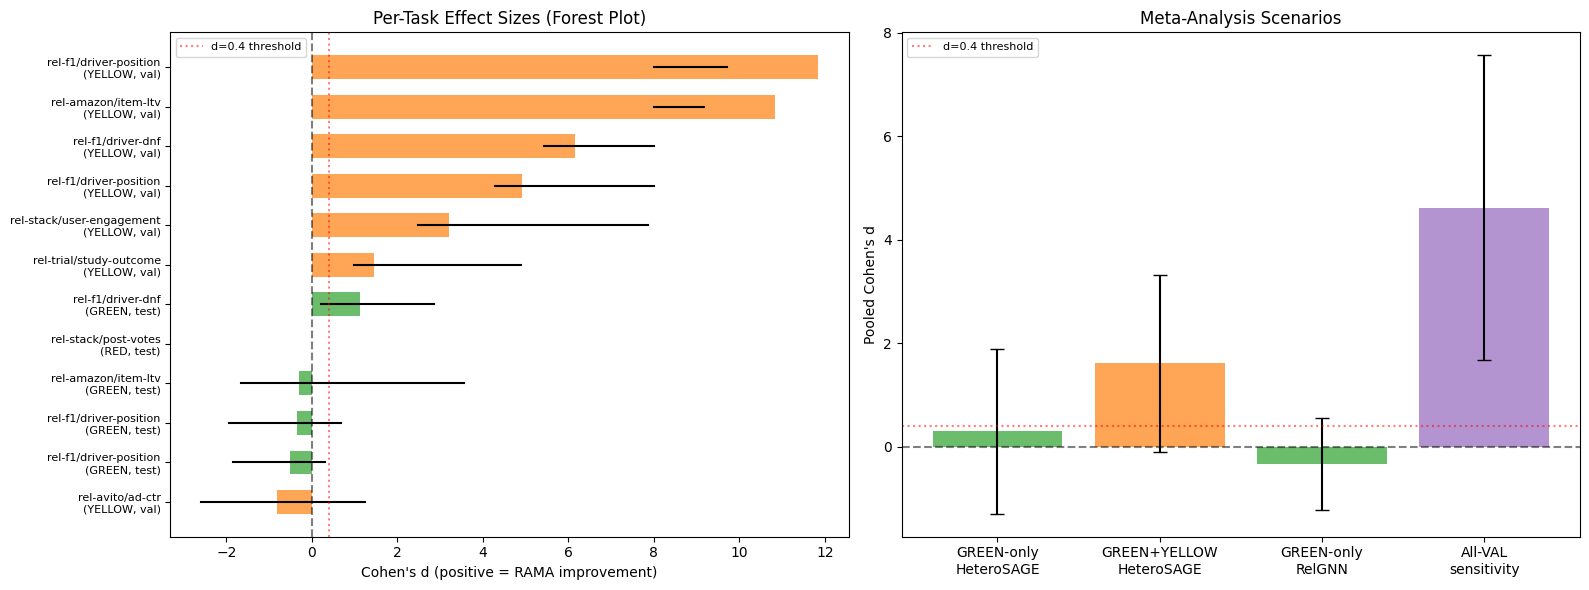

Saved: meta_analysis_results.png


In [12]:
# --- Forest plot for GREEN+YELLOW tasks ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Panel 1: Forest plot (per-task effect sizes with CIs)
ax = axes[0]
# Filter to non-degenerate tasks (|d| < 20) for readability
plot_rows = [r for r in effect_size_rows if abs(r["d"]) < 20]
plot_rows.sort(key=lambda x: x["d"])

y_pos = range(len(plot_rows))
ds = [r["d"] for r in plot_rows]
ci_los = [r["ci_lo"] for r in plot_rows]
ci_his = [r["ci_hi"] for r in plot_rows]
labels = [f"{r['task']}\n({r['grade']}, {r['eval']})" for r in plot_rows]
colors = {"GREEN": "#2ca02c", "YELLOW": "#ff7f0e", "RED": "#d62728"}
bar_colors = [colors.get(r["grade"], "#999999") for r in plot_rows]

# Clip CIs for display
ci_lo_clip = [max(ci, -5) for ci in ci_los]
ci_hi_clip = [min(ci, 8) for ci in ci_his]

ax.barh(y_pos, ds, color=bar_colors, alpha=0.7, height=0.6)
for i, (d, lo, hi) in enumerate(zip(ds, ci_lo_clip, ci_hi_clip)):
    ax.plot([lo, hi], [i, i], color="black", linewidth=1.5)
ax.axvline(x=0, color="black", linestyle="--", alpha=0.5)
ax.axvline(x=0.4, color="red", linestyle=":", alpha=0.5, label="d=0.4 threshold")
ax.set_yticks(y_pos)
ax.set_yticklabels(labels, fontsize=8)
ax.set_xlabel("Cohen's d (positive = RAMA improvement)")
ax.set_title("Per-Task Effect Sizes (Forest Plot)")
ax.legend(fontsize=8)

# Panel 2: Meta-analysis pooled d comparison
ax2 = axes[1]
scenarios = ["GREEN-only\nHeteroSAGE", "GREEN+YELLOW\nHeteroSAGE",
             "GREEN-only\nRelGNN", "All-VAL\nsensitivity"]
pooled_ds = [ma_green["pooled_d"], ma_gy["pooled_d"],
             ma_relgnn["pooled_d"], ma_allval["pooled_d"]]
pooled_ci_lo = [ma_green["ci_lo"], ma_gy["ci_lo"],
                ma_relgnn["ci_lo"], ma_allval["ci_lo"]]
pooled_ci_hi = [ma_green["ci_hi"], ma_gy["ci_hi"],
                ma_relgnn["ci_hi"], ma_allval["ci_hi"]]
errs_lo = [d - lo for d, lo in zip(pooled_ds, pooled_ci_lo)]
errs_hi = [hi - d for d, hi in zip(pooled_ds, pooled_ci_hi)]
bar_cols = ["#2ca02c", "#ff7f0e", "#2ca02c", "#9467bd"]

ax2.bar(scenarios, pooled_ds, color=bar_cols, alpha=0.7)
ax2.errorbar(scenarios, pooled_ds, yerr=[errs_lo, errs_hi],
             fmt="none", ecolor="black", capsize=5)
ax2.axhline(y=0.4, color="red", linestyle=":", alpha=0.5, label="d=0.4 threshold")
ax2.axhline(y=0, color="black", linestyle="--", alpha=0.5)
ax2.set_ylabel("Pooled Cohen's d")
ax2.set_title("Meta-Analysis Scenarios")
ax2.legend(fontsize=8)

plt.tight_layout()
plt.savefig("meta_analysis_results.png", dpi=100, bbox_inches="tight")
plt.show()
print("Saved: meta_analysis_results.png")